# Explainable AI (XAI) Analysis — N-CMAPSS RUL Transformer Models

Comprehensive XAI for all DS1-DS9 dataset/model pairs.

## Dataset & Model Mapping
| Index | Dataset File | Model 1 | Model 2 |
|---|---|---|---|
| 0 | N-CMAPSS_DS01-005.h5 | best_1.keras | best_1_2.keras |
| 1 | N-CMAPSS_DS02-006.h5 | best_2.keras | best_2_0.keras |
| 2 | N-CMAPSS_DS03-012.h5 | best_DS03.keras | best_DS03_copy.keras |
| 3 | N-CMAPSS_DS03-012.h5 | best_DS03_5.keras | best_DS03_5_copy.keras |
| 4 | N-CMAPSS_DS04.h5 | best_DS04.keras | best_DS04_copy.keras |
| 5 | N-CMAPSS_DS05.h5 | best_DS5.keras | best_DS5_copy.keras |
| 6 | N-CMAPSS_DS06.h5 | best_DS6.keras | best_DS6_copy.keras |
| 7 | N-CMAPSS_DS07.h5 | best_DS7.keras | best_DS7_copy.keras |
| 8 | N-CMAPSS_DS08a-009.h5 | best_DS8.keras | best_DS8_copy.keras |
| 9 | N-CMAPSS_DS08c-008.h5 | best_DS9.keras | best_DS9_copy.keras |

## XAI Methods
1. Integrated Gradients  2. Attention Weights  3. SHAP GradientExplainer
4. Permutation Importance  5. Temporal Sensitivity  6. Feature-RUL Correlation

## Bugs Fixed in This Notebook
- **h5py 3.x string bug**: `np.array(dataset, dtype='U20')` fails in h5py 3.x -- replaced with `_decode_var_names()` that reads raw bytes and decodes them.
- **SHAP 0.51 shape bug**: `GradientExplainer` returns `(N, W, F, 1)` for single-output models -- fixed with `_squeeze_shap()` + `.flatten()` on all aggregation results.


## Section 0: Configuration -- Edit This Cell

In [1]:
# =============================================================
# CONFIGURATION -- Edit this cell to select dataset/model
# =============================================================

DATASET_INDEX  = 0        # 0-9 (see table above)
MODEL_VARIANT  = 'model2' # 'model1' or 'model2'
BASE_DIR       = '.'      # base directory containing data_set/ and models/

SHAP_BACKGROUND_SAMPLES = 200  # SHAP background samples (lower = faster)
SHAP_EXPLAIN_SAMPLES    = 50   # samples to explain with SHAP
PERM_ITERATIONS         = 10   # permutation importance iterations
SEED                    = 42

SAVE_FIGURES = True
FIG_DIR = f'./xai_results/{MODEL_VARIANT}/DS{DATASET_INDEX:02d}'

WINDOW_SIZE = 30   # must match training
STRIDE      = 15   # must match training

print(f'Config: DATASET_INDEX={DATASET_INDEX}, MODEL_VARIANT={MODEL_VARIANT}')


Config: DATASET_INDEX=0, MODEL_VARIANT=model2


## Section 1: Imports & Setup

In [2]:
import gc; gc.collect()
import subprocess, sys, os

# Fix: TF 2.17 requires numpy < 2.0. If numpy 2.x is loaded, downgrade and restart.
import numpy as np
if int(np.__version__.split('.')[0]) >= 2:
    print(f'numpy {np.__version__} incompatible with TF — downgrading to 1.26.4...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy==1.26.4', '-q', '--force-reinstall'])
    print('\n⚠️  Kernel restart required! Do: Kernel > Restart & Run All')
    raise SystemExit('Restart kernel now.')

import pandas as pd
import h5py, time, json, warnings
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import shap
    print(f'SHAP {shap.__version__}')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

print(f'TF {tf.__version__}  numpy {np.__version__}')
if SAVE_FIGURES:
    os.makedirs(FIG_DIR, exist_ok=True)
    print(f'Figures -> {FIG_DIR}')


2026-06-19 17:05:12.342303: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-19 17:05:12.351011: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-19 17:05:12.359663: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-19 17:05:12.362147: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-19 17:05:12.368823: I tensorflow/core/platform/cpu_feature_guar

SHAP 0.51.0
TF 2.17.0  numpy 1.26.4
Figures -> ./xai_results/model2/DS00


## Section 2: Dataset & Model Paths

In [3]:
DATASET_CONFIG = [
    # (dataset_file,              model1_file,            model2_file,             label)
    ('N-CMAPSS_DS01-005.h5',     'best_1.keras',         'best_1_2.keras',        'DS01'),
    ('N-CMAPSS_DS02-006.h5',     'best_2.keras',         'best_2_0.keras',        'DS02'),
    ('N-CMAPSS_DS03-012.h5',     'best_DS03.keras',      'best_DS03_copy.keras',  'DS03'),
    ('N-CMAPSS_DS03-012.h5',     'best_DS03_5.keras',    'best_DS03_5_copy.keras','DS03_5'),
    ('N-CMAPSS_DS04.h5',         'best_DS04.keras',      'best_DS04_copy.keras',  'DS04'),
    ('N-CMAPSS_DS05.h5',         'best_DS5.keras',       'best_DS5_copy.keras',   'DS05'),
    ('N-CMAPSS_DS06.h5',         'best_DS6.keras',       'best_DS6_copy.keras',   'DS06'),
    ('N-CMAPSS_DS07.h5',         'best_DS7.keras',       'best_DS7_copy.keras',   'DS07'),
    ('N-CMAPSS_DS08a-009.h5',    'best_DS8.keras',       'best_DS8_copy.keras',   'DS08a'),
    ('N-CMAPSS_DS08c-008.h5',    'best_DS9.keras',       'best_DS9_copy.keras',   'DS08c'),
]

cfg_row = DATASET_CONFIG[DATASET_INDEX]
DATASET_FILE  = os.path.join(BASE_DIR, 'data_set', cfg_row[0])
MODEL_FILE    = os.path.join(BASE_DIR, 'models',
                              cfg_row[1] if MODEL_VARIANT == 'model1' else cfg_row[2])
DATASET_LABEL = cfg_row[3]

print(f'Dataset : {DATASET_FILE}')
print(f'Model   : {MODEL_FILE}')
print(f'Label   : {DATASET_LABEL}')

assert os.path.exists(DATASET_FILE), f'Dataset not found: {DATASET_FILE}'
assert os.path.exists(MODEL_FILE),   f'Model not found: {MODEL_FILE}'
print('Paths verified.')


Dataset : ./data_set/N-CMAPSS_DS01-005.h5
Model   : ./models/best_1_2.keras
Label   : DS01
Paths verified.


## Section 3: Load & Preprocess Data

In [4]:
# FIX: h5py 3.x stores variable-length strings as bytes objects.
# np.array(hdf_dataset, dtype='U20') raises TypeError in h5py >= 3.0.
# Solution: read raw with dataset[()] then decode each item as UTF-8.
def _decode_var_names(hdf_dataset):
    raw = hdf_dataset[()]
    result = []
    for item in raw:
        if isinstance(item, (bytes, np.bytes_)):
            result.append(item.decode('utf-8').strip())
        else:
            result.append(str(item).strip())
    return result

def read_hdf(filename):
    t = time.process_time()
    with h5py.File(filename, 'r') as hdf:
        W_dev    = np.array(hdf['W_dev'],    dtype=np.float32)
        X_s_dev  = np.array(hdf['X_s_dev'],  dtype=np.float32)
        X_v_dev  = np.array(hdf['X_v_dev'],  dtype=np.float32)
        T_dev    = np.array(hdf['T_dev'],    dtype=np.float32)
        Y_dev    = np.array(hdf['Y_dev'],    dtype=np.float32)
        A_dev    = np.array(hdf['A_dev'],    dtype=np.float32)
        W_test   = np.array(hdf['W_test'],   dtype=np.float32)
        X_s_test = np.array(hdf['X_s_test'], dtype=np.float32)
        X_v_test = np.array(hdf['X_v_test'], dtype=np.float32)
        T_test   = np.array(hdf['T_test'],   dtype=np.float32)
        Y_test   = np.array(hdf['Y_test'],   dtype=np.float32)
        A_test   = np.array(hdf['A_test'],   dtype=np.float32)
        # Use _decode_var_names -- NOT np.array(..., dtype='U20')
        W_var    = _decode_var_names(hdf['W_var'])
        X_s_var  = _decode_var_names(hdf['X_s_var'])
        X_v_var  = _decode_var_names(hdf['X_v_var'])
        T_var    = _decode_var_names(hdf['T_var'])
        A_var    = _decode_var_names(hdf['A_var'])

    trainx = pd.concat([pd.DataFrame(X_s_dev, columns=X_s_var),
                        pd.DataFrame(W_dev,   columns=W_var)], axis=1)
    trainy = pd.DataFrame(Y_dev, columns=['RUL'])
    adev   = pd.DataFrame(A_dev, columns=A_var)
    testx  = pd.concat([pd.DataFrame(X_s_test, columns=X_s_var),
                        pd.DataFrame(W_test,   columns=W_var)], axis=1)
    testy  = pd.DataFrame(Y_test, columns=['RUL'])
    atest  = pd.DataFrame(A_test, columns=A_var)

    print(f'Train X: {trainx.shape}  Train Y: {trainy.shape}')
    print(f'Test  X: {testx.shape}   Test  Y: {testy.shape}')
    print(f'Load time: {(time.process_time()-t)/60:.3f} min')
    return trainx, trainy, adev, testx, testy, atest

trainx, trainy, adev, testx, testy, atest = read_hdf(DATASET_FILE)
FEATURE_NAMES = list(trainx.columns)
print(f'\nFeatures ({len(FEATURE_NAMES)}): {FEATURE_NAMES}')


Train X: (4906636, 18)  Train Y: (4906636, 1)
Test  X: (2735232, 18)   Test  Y: (2735232, 1)
Load time: 0.031 min

Features (18): ['T24', 'T30', 'T48', 'T50', 'P15', 'P2', 'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf', 'alt', 'Mach', 'TRA', 'T2']


In [5]:
sc = StandardScaler()
sc.fit(trainx.values)
trainx_sc = pd.DataFrame(sc.transform(trainx.values).astype(np.float32), columns=FEATURE_NAMES)
testx_sc  = pd.DataFrame(sc.transform(testx.values).astype(np.float32),  columns=FEATURE_NAMES)

trainy_filt = trainy[trainy != 0].dropna()
trainx_sc   = trainx_sc.loc[trainy_filt.index]
testy_filt  = testy[testy != 0].dropna()
testx_sc    = testx_sc.loc[testy_filt.index]
print(f'After filtering -- Train: {trainx_sc.shape}, Test: {testx_sc.shape}')

rul_scaler = None
if MODEL_VARIANT == 'model2':
    rul_scaler = StandardScaler()
    rul_scaler.fit(trainy_filt.values.reshape(-1, 1).astype(np.float32))
    print(f'RUL Scaler: mean={rul_scaler.mean_[0]:.2f}, std={rul_scaler.scale_[0]:.2f}')


After filtering -- Train: (4849640, 18), Test: (2699669, 18)
RUL Scaler: mean=45.36, std=26.34


In [6]:
def time_window_slicing_sample(df, window_length, unit, seq_cols, stride=1):
    d = df[df['unit'] == unit][seq_cols].values.astype(np.float32)
    n = int((d.shape[0] - window_length) / stride) + 1
    return np.dstack([d[i*stride:i*stride+window_length] for i in range(n)]).astype(np.float32)

def time_window_slicing_label(df, window_length, unit, stride=1):
    d = df[df['unit'] == unit]['RUL'].values.astype(np.float32)
    n = int((d.shape[0] - window_length) / stride) + 1
    return np.array([d[i*stride:i*stride+window_length][-1] for i in range(n)])

df_test = testx_sc.copy()
df_test['unit'] = atest['unit'].values[testy_filt.index]
df_test['RUL']  = testy_filt['RUL'].values
feat_cols = df_test.columns.difference(['unit', 'RUL'])

windows, labels = [], []
for un in df_test['unit'].unique():
    windows.append(time_window_slicing_sample(df_test, WINDOW_SIZE, un, feat_cols, STRIDE))
    labels.extend(time_window_slicing_label(df_test, WINDOW_SIZE, un, STRIDE).tolist())

test_units_data = np.dstack(windows).transpose(2, 0, 1).astype(np.float32)
test_labels_raw = np.array(labels, dtype=np.float32)
print(f'Test windows: {test_units_data.shape}  Labels: {test_labels_raw.shape}')

np.random.seed(SEED)
n_sub = min(len(test_units_data), max(SHAP_EXPLAIN_SAMPLES * 4, 1000))
idx_sub    = np.random.choice(len(test_units_data), n_sub, replace=False)
X_test_sub = test_units_data[idx_sub]
y_test_sub = test_labels_raw[idx_sub]
print(f'XAI subset: {X_test_sub.shape}')


Test windows: (179971, 30, 18)  Labels: (179971,)
XAI subset: (1000, 30, 18)


## Section 4: Load Trained Model

In [7]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.d_model = d_model
    def build(self, input_shape):
        self.pos_encoding = self.add_weight(
            name='pos_encoding', shape=(self.sequence_length, self.d_model),
            initializer='uniform', trainable=True)
        super().build(input_shape)
    def call(self, inputs): return inputs + self.pos_encoding
    def get_config(self):
        c = super().get_config()
        c.update({'sequence_length': self.sequence_length, 'd_model': self.d_model})
        return c

class ReduceSumLayer(tf.keras.layers.Layer):
    def call(self, x): return tf.reduce_sum(x, axis=1)
    def get_config(self): return super().get_config()

class Shape(tf.keras.layers.Layer):
    def call(self, x): return tf.shape(x)
    def get_config(self): return super().get_config()

CUSTOM_OBJECTS = {
    'PositionalEncoding': PositionalEncoding,
    'ReduceSumLayer': ReduceSumLayer,
    'Shape': Shape,
}

print(f'Loading: {MODEL_FILE}')
model = keras.models.load_model(MODEL_FILE, custom_objects=CUSTOM_OBJECTS)
model.summary()
print(f'\nModel loaded -- params: {model.count_params():,}')


Loading: ./models/best_1_2.keras


I0000 00:00:1781888727.718849   10513 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781888727.887022   10513 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781888727.887083   10513 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781888727.890085   10513 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781888727.890142   10513 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 32)    │      1,728 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 32)    │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 32)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 18)    │        576 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 18)    │         72 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 18)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 18)    │         36 │ dropout_1[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 18)    │      4,608 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 18)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 18)    │          0 │ dropout_3[0][0],  │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 18)    │         36 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 128)   │      2,304 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 18)    │      2,304 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 18)    │          0 │ dense_1[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 18)    │         36 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 18)    │      4,608 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 30, 18)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 18)    │          0 │ dropout_6[0][0],

 Total params: 130,192 (508.57 KB)

 Trainable params: 64,885 (253.46 KB)

 Non-trainable params: 420 (1.64 KB)

 Optimizer params: 64,887 (253.47 KB)


Model loaded -- params: 65,305


In [8]:
def _predict_inv(X):
    """Predict and inverse-transform RUL if model2."""
    p = model.predict(X, batch_size=512, verbose=0).flatten()
    if MODEL_VARIANT == 'model2' and rul_scaler is not None:
        p = rul_scaler.inverse_transform(p.reshape(-1, 1)).flatten()
    return p

y_pred = _predict_inv(test_units_data)
y_true = test_labels_raw
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print(f'{DATASET_LABEL} | {MODEL_VARIANT}')
print(f'  MAE  = {mae:.4f} cycles')
print(f'  RMSE = {rmse:.4f} cycles')
print(f'  R2   = {r2:.4f}')


I0000 00:00:1781888730.128364   10716 service.cc:146] XLA service 0x740680006830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781888730.128392   10716 service.cc:154]   StreamExecutor device (0): NVIDIA RTX 4000 Ada Generation, Compute Capability 8.9
2026-06-19 17:05:30.166741: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-19 17:05:30.272518: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90101
2026-06-19 17:05:29.969630: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1196', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1781888731.001888   10716 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.

DS01 | model2
  MAE  = 4.9285 cycles
  RMSE = 7.1757 cycles
  R2   = 0.9117


## Section 5: Prediction Analysis & Error Plots

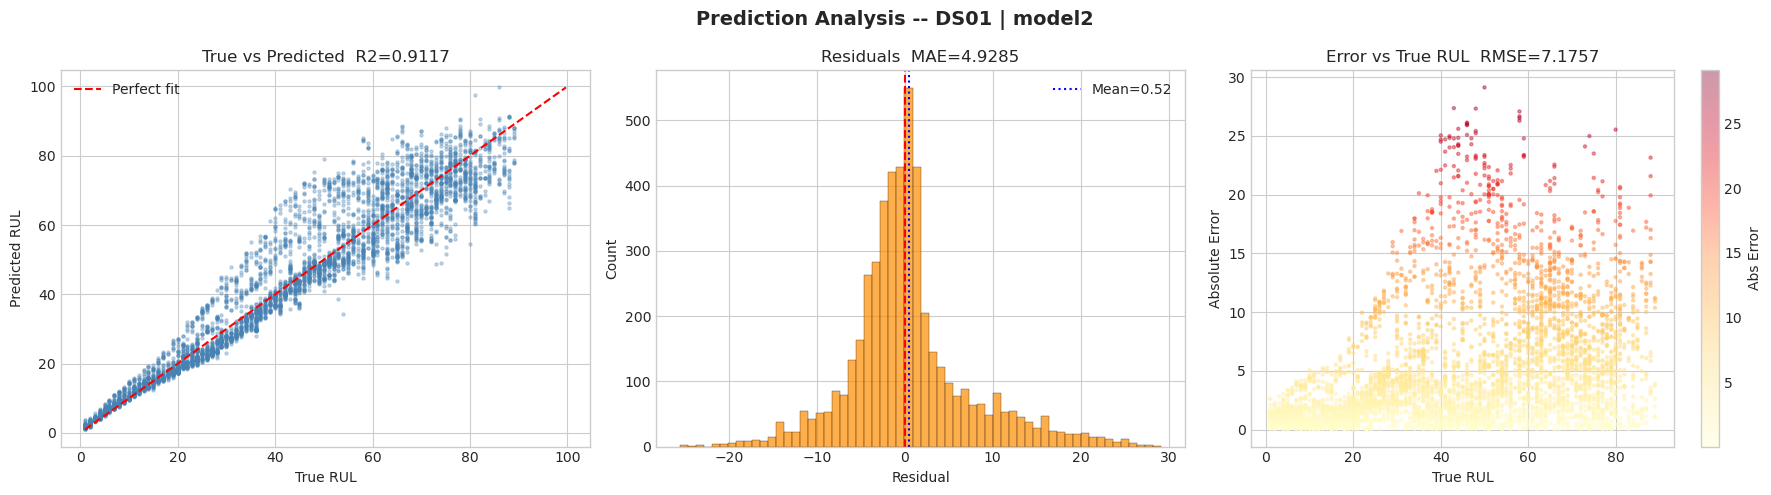

In [9]:
plot_n   = min(5000, len(y_true))
np.random.seed(SEED)
pidx = np.random.choice(len(y_true), plot_n, replace=False)
y_tp = y_true[pidx];  y_pp = y_pred[pidx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Prediction Analysis -- {DATASET_LABEL} | {MODEL_VARIANT}', fontsize=14, fontweight='bold')

ax = axes[0]
ax.scatter(y_tp, y_pp, alpha=0.3, s=5, c='steelblue')
lims = [min(y_tp.min(), y_pp.min()), max(y_tp.max(), y_pp.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('True RUL'); ax.set_ylabel('Predicted RUL')
ax.set_title(f'True vs Predicted  R2={r2:.4f}'); ax.legend(markerscale=3)

ax = axes[1]
res = y_pp - y_tp
ax.hist(res, bins=60, color='darkorange', alpha=0.7, edgecolor='black', linewidth=0.3)
ax.axvline(0, color='red', lw=1.5, ls='--')
ax.axvline(res.mean(), color='blue', lw=1.5, ls=':', label=f'Mean={res.mean():.2f}')
ax.set_xlabel('Residual'); ax.set_ylabel('Count')
ax.set_title(f'Residuals  MAE={mae:.4f}'); ax.legend()

ax = axes[2]
ae = np.abs(res)
sc_p = ax.scatter(y_tp, ae, c=ae, cmap='YlOrRd', alpha=0.4, s=5)
plt.colorbar(sc_p, ax=ax, label='Abs Error')
ax.set_xlabel('True RUL'); ax.set_ylabel('Absolute Error')
ax.set_title(f'Error vs True RUL  RMSE={rmse:.4f}')

plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/01_prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()


## Section 6: Integrated Gradients

In [ ]:
def compute_saliency(model, X_batch, n_steps=30):
    """Integrated Gradients -- returns (N, W, F)."""
    X_batch  = tf.cast(X_batch, tf.float32)
    baseline = tf.zeros_like(X_batch)
    alphas   = tf.linspace(0.0, 1.0, n_steps + 1)[1:]
    grads_list = []
    for alpha in alphas:
        interp = baseline + alpha * (X_batch - baseline)
        with tf.GradientTape() as tape:
            tape.watch(interp)
            preds = model(interp, training=False)
        grads_list.append(tape.gradient(preds, interp))
    avg_g = tf.reduce_mean(tf.stack(grads_list, axis=0), axis=0)
    return ((X_batch - baseline) * avg_g).numpy()

print('Computing Integrated Gradients...')
ig_idx = np.random.choice(len(X_test_sub), min(64, len(X_test_sub)), replace=False)
saliency = compute_saliency(model, X_test_sub[ig_idx])
sal_abs  = np.abs(saliency)

# Aggregate -- always .flatten() to guarantee 1-D
feature_ig  = sal_abs.mean(axis=(0, 1)).flatten()  # (F,)
temporal_ig = sal_abs.mean(axis=(0, 2)).flatten()  # (W,)
print(f'IG shape: {saliency.shape}  feature_ig: {feature_ig.shape}  temporal_ig: {temporal_ig.shape}')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(f'Integrated Gradients -- {DATASET_LABEL} | {MODEL_VARIANT}', fontsize=14, fontweight='bold')

ax = axes[0]
srt_ig = np.argsort(feature_ig)[::-1]
ax.bar(range(len(FEATURE_NAMES)), feature_ig[srt_ig],
       color=plt.cm.viridis(np.linspace(0.2, 0.9, len(FEATURE_NAMES))))
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels([FEATURE_NAMES[i] for i in srt_ig], rotation=45, ha='right')
ax.set_xlabel('Feature'); ax.set_ylabel('Mean |IG|')
ax.set_title('Feature Importance (Integrated Gradients)')

ax = axes[1]
ax.plot(range(WINDOW_SIZE), temporal_ig, marker='o', markersize=4, lw=1.5, color='darkorange')
ax.fill_between(range(WINDOW_SIZE), temporal_ig, alpha=0.25, color='darkorange')
ax.axvline(WINDOW_SIZE - 1, color='red', ls='--', lw=1, label='Last timestep')
ax.set_xlabel('Timestep'); ax.set_ylabel('Mean |IG|')
ax.set_title('Temporal Importance (Integrated Gradients)'); ax.legend()

plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/02_integrated_gradients.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()


Computing Integrated Gradients...


W0000 00:00:1781888734.664347   10513 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1781888734.676835   10513 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1781888734.677300   10513 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1781888734.677707   10513 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1781888734.685942   10513 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1781888734.686393   10513 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1781888734.687352   10513 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1781888734.687759   10513 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1781888734.688171   10513 gp

## Section 7: Attention Weight Analysis

In [ ]:
def extract_attention_weights(model, X_sample):
    attn_layers = [(l.name, l) for l in model.layers
                   if isinstance(l, tf.keras.layers.MultiHeadAttention)]
    if not attn_layers:
        print('No MultiHeadAttention layers found.')
        return {}
    print(f'Found {len(attn_layers)} MHA layers: {[n for n,_ in attn_layers]}')
    X_tf = tf.cast(X_sample[:8], tf.float32)
    results = {}
    for name, layer in attn_layers:
        try:
            layer_input = layer.input if hasattr(layer, 'input') else None
            if layer_input is not None:
                feat = tf.keras.Model(inputs=model.input, outputs=layer_input)(X_tf, training=False)
                _, scores = layer(feat, feat, return_attention_scores=True, training=False)
                results[name] = scores.numpy()
                print(f'  {name}: {scores.shape}')
        except Exception as e:
            print(f'  {name}: {e}')
    return results

print('Extracting attention weights...')
attention_dict = extract_attention_weights(model, X_test_sub)

if attention_dict:
    n_lay = len(attention_dict)
    fig, axes = plt.subplots(1, min(n_lay, 4), figsize=(5*min(n_lay,4), 5))
    if n_lay == 1: axes = [axes]
    fig.suptitle(f'Attention Weights -- {DATASET_LABEL} | {MODEL_VARIANT}', fontsize=13, fontweight='bold')
    for ax, (lname, scores) in zip(axes, list(attention_dict.items())[:4]):
        im = ax.imshow(scores.mean(axis=(0,1)), cmap='viridis', aspect='auto')
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(lname, fontsize=10)
        ax.set_xlabel('Key timestep'); ax.set_ylabel('Query timestep')
    for ax in axes[n_lay:]: ax.set_visible(False)
    plt.tight_layout()
    if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/03_attention_weights.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

    fig, axes = plt.subplots(1, min(n_lay, 4), figsize=(5*min(n_lay,4), 4))
    if n_lay == 1: axes = [axes]
    fig.suptitle(f'Attention by Timestep -- {DATASET_LABEL} | {MODEL_VARIANT}', fontsize=13, fontweight='bold')
    for ax, (lname, scores) in zip(axes, list(attention_dict.items())[:4]):
        ax.bar(range(scores.mean(axis=(0,1)).shape[0]),
               scores.mean(axis=(0,1)).sum(axis=0), color='steelblue', alpha=0.8)
        ax.set_xlabel('Timestep'); ax.set_ylabel('Total attention received')
        ax.set_title(lname, fontsize=10)
    for ax in axes[n_lay:]: ax.set_visible(False)
    plt.tight_layout()
    if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/04_attention_by_timestep.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
else:
    print('No attention weights extracted -- skipping attention plots.')


## Section 8: SHAP Analysis

In [ ]:
# FIX: SHAP 0.51 GradientExplainer returns (N, W, F, 1) for single-output models.
# We must squeeze that trailing dimension before any aggregation or plotting.
def _squeeze_shap(sv):
    """Squeeze trailing 1-size output dimensions. Ensures shape is (N, W, F)."""
    sv = np.array(sv)
    while sv.ndim > 3 and sv.shape[-1] == 1:
        sv = sv.squeeze(-1)   # (N,W,F,1) -> (N,W,F)
    if sv.ndim == 4:
        sv = sv[..., 0]       # multi-output: take first output
    return sv

print('Setting up SHAP...')
bg_idx = np.random.choice(len(X_test_sub), min(SHAP_BACKGROUND_SAMPLES, len(X_test_sub)), replace=False)
ex_idx = np.random.choice(len(X_test_sub), min(SHAP_EXPLAIN_SAMPLES, len(X_test_sub)), replace=False)
X_bg, X_ex = X_test_sub[bg_idx], X_test_sub[ex_idx]
print(f'Background: {X_bg.shape}  Explain: {X_ex.shape}')

SHAP_SUCCESS = False
try:
    explainer    = shap.GradientExplainer(model, X_bg)
    shap_raw     = explainer.shap_values(X_ex)
    sv           = _squeeze_shap(shap_raw[0] if isinstance(shap_raw, list) else shap_raw)
    print(f'SHAP GradientExplainer -- shape after squeeze: {sv.shape}')
    SHAP_SUCCESS = True
except Exception as e:
    print(f'GradientExplainer failed ({e}), falling back to KernelExplainer...')
    X_bg_2d = X_bg.reshape(len(X_bg), -1)
    X_ex_2d = X_ex.reshape(len(X_ex), -1)
    def _pred_flat(Xf):
        return model.predict(Xf.reshape(-1, WINDOW_SIZE, len(FEATURE_NAMES)), verbose=0).flatten()
    bg_km    = shap.kmeans(X_bg_2d, min(50, len(X_bg_2d)))
    kexp     = shap.KernelExplainer(_pred_flat, bg_km)
    sv_2d    = np.array(kexp.shap_values(X_ex_2d[:20], nsamples=100))
    if sv_2d.ndim == 3: sv_2d = sv_2d[0]
    sv       = sv_2d.reshape(-1, WINDOW_SIZE, len(FEATURE_NAMES))
    X_ex     = X_ex[:len(sv)]
    print(f'SHAP KernelExplainer -- shape: {sv.shape}')
    SHAP_SUCCESS = True

if SHAP_SUCCESS:
    sv_abs = np.abs(sv)
    # Always .flatten() -- eliminates any residual trailing dimensions
    shap_feature_imp  = sv_abs.mean(axis=(0, 1)).flatten()  # (F,)
    shap_temporal_imp = sv_abs.mean(axis=(0, 2)).flatten()  # (W,)
    print(f'shap_feature_imp shape: {shap_feature_imp.shape}   (expected ({len(FEATURE_NAMES)},))')
    print(f'shap_temporal_imp shape: {shap_temporal_imp.shape}  (expected ({WINDOW_SIZE},))')

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(f'SHAP Analysis -- {DATASET_LABEL} | {MODEL_VARIANT}', fontsize=14, fontweight='bold')

    ax = axes[0]
    srt_shap = np.argsort(shap_feature_imp)[::-1]
    ax.bar(range(len(FEATURE_NAMES)), shap_feature_imp[srt_shap],
           color=plt.cm.plasma(np.linspace(0.1, 0.9, len(FEATURE_NAMES))))
    ax.set_xticks(range(len(FEATURE_NAMES)))
    ax.set_xticklabels([FEATURE_NAMES[i] for i in srt_shap], rotation=45, ha='right')
    ax.set_xlabel('Feature'); ax.set_ylabel('Mean |SHAP|')
    ax.set_title('Feature Importance (SHAP)')

    ax = axes[1]
    ax.plot(range(WINDOW_SIZE), shap_temporal_imp, marker='o', markersize=4, lw=1.5, color='purple')
    ax.fill_between(range(WINDOW_SIZE), shap_temporal_imp, alpha=0.2, color='purple')
    ax.axvline(WINDOW_SIZE-1, color='red', lw=1, ls='--', label='Last timestep')
    ax.set_xlabel('Timestep'); ax.set_ylabel('Mean |SHAP|')
    ax.set_title('Temporal Importance (SHAP)'); ax.legend()

    plt.tight_layout()
    if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/05_shap_importance.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

    mean_shap_map = sv_abs.mean(axis=0)  # (W, F)
    if mean_shap_map.ndim == 3: mean_shap_map = mean_shap_map.squeeze(-1)
    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(mean_shap_map.T, cmap='hot', aspect='auto', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Mean |SHAP|')
    ax.set_xlabel('Timestep'); ax.set_ylabel('Feature')
    ax.set_yticks(range(len(FEATURE_NAMES))); ax.set_yticklabels(FEATURE_NAMES, fontsize=9)
    ax.set_title(f'SHAP Heatmap -- {DATASET_LABEL} | {MODEL_VARIANT}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/06_shap_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()


## Section 9: Permutation Feature Importance

In [ ]:
print(f'Permutation importance ({PERM_ITERATIONS} iters)...')
perm_n = min(2000, len(X_test_sub))
pm_idx = np.random.choice(len(X_test_sub), perm_n, replace=False)
X_pm, y_pm = X_test_sub[pm_idx], y_test_sub[pm_idx]
bl_mae = mean_absolute_error(y_pm, _predict_inv(X_pm))
print(f'Baseline MAE: {bl_mae:.4f}')

perm_importance = np.zeros(len(FEATURE_NAMES))
for fi in range(len(FEATURE_NAMES)):
    maes = []
    for _ in range(PERM_ITERATIONS):
        Xp = X_pm.copy()
        Xp[:, :, fi] = Xp[np.random.permutation(perm_n), :, fi]
        maes.append(mean_absolute_error(y_pm, _predict_inv(Xp)))
    perm_importance[fi] = np.mean(maes) - bl_mae
print('Done.')

srt_p = np.argsort(perm_importance)[::-1]
fig, ax = plt.subplots(figsize=(12, 5))
colors_p = ['tomato' if v >= 0 else 'steelblue' for v in perm_importance[srt_p]]
ax.bar(range(len(FEATURE_NAMES)), perm_importance[srt_p], color=colors_p, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels([FEATURE_NAMES[i] for i in srt_p], rotation=45, ha='right')
ax.set_xlabel('Feature'); ax.set_ylabel('delta MAE')
ax.set_title(f'Permutation Importance -- {DATASET_LABEL} | {MODEL_VARIANT}', fontsize=13, fontweight='bold')
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/07_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()


## Section 10: Temporal Sensitivity (Masking)

In [ ]:
print('Temporal sensitivity...')
ts_n = min(500, len(X_test_sub))
ts_i = np.random.choice(len(X_test_sub), ts_n, replace=False)
X_ts, y_ts = X_test_sub[ts_i], y_test_sub[ts_i]
ts_bl = mean_absolute_error(y_ts, _predict_inv(X_ts))

timestep_importance = np.zeros(WINDOW_SIZE)
for t in range(WINDOW_SIZE):
    Xm = X_ts.copy(); Xm[:, t, :] = 0.0
    timestep_importance[t] = mean_absolute_error(y_ts, _predict_inv(Xm)) - ts_bl
print(f'Done. Baseline MAE: {ts_bl:.4f}')

fig, ax = plt.subplots(figsize=(12, 4))
colors_ts = ['tomato' if v >= 0 else 'steelblue' for v in timestep_importance]
ax.bar(range(WINDOW_SIZE), timestep_importance, color=colors_ts, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Timestep (0=oldest, last=most recent)')
ax.set_ylabel('delta MAE (masked - baseline)')
ax.set_title(f'Temporal Sensitivity -- {DATASET_LABEL} | {MODEL_VARIANT}', fontsize=13, fontweight='bold')
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/08_temporal_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()


## Section 11: Feature-RUL Correlation

In [ ]:
corr_n = min(50000, len(trainx))
ci = np.random.choice(len(trainx), corr_n, replace=False)
df_c = trainx.iloc[ci].copy()
df_c['RUL'] = trainy.iloc[ci]['RUL'].values

pearson_corr  = df_c.corr(method='pearson')['RUL'].drop('RUL')
spearman_corr = df_c.corr(method='spearman')['RUL'].drop('RUL')
srt_c = pearson_corr.abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Feature-RUL Correlation -- {DATASET_LABEL}', fontsize=14, fontweight='bold')
for ax, corr, title in zip(axes, [pearson_corr, spearman_corr], ['Pearson', 'Spearman']):
    vals = corr[srt_c.index].values
    ax.barh(srt_c.index, vals,
            color=['tomato' if v < 0 else 'steelblue' for v in vals], alpha=0.85)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel(f'{title} Correlation'); ax.set_title(f'{title} Correlation')
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/09_feature_rul_correlation.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()


## Section 12: Consolidated Feature Importance Summary

In [ ]:
df_sum = pd.DataFrame({'Feature': FEATURE_NAMES}).set_index('Feature')

# Always .flatten() before assigning to ensure 1-D Series alignment
df_sum['IG_Score']   = feature_ig.flatten() / (feature_ig.flatten().sum() + 1e-10)
perm_c = np.maximum(perm_importance, 0)
df_sum['Perm_Score'] = perm_c / (perm_c.sum() + 1e-10)
if SHAP_SUCCESS:
    df_sum['SHAP_Score'] = shap_feature_imp / (shap_feature_imp.sum() + 1e-10)
df_sum['|Pearson|'] = pearson_corr.abs().values

avg_cols = [c for c in ['IG_Score','Perm_Score','SHAP_Score'] if c in df_sum.columns]
df_sum['Ensemble'] = df_sum[avg_cols].mean(axis=1)
df_sum['Rank']     = df_sum['Ensemble'].rank(ascending=False).astype(int)
df_sum.sort_values('Rank', inplace=True)

print(f'XAI Summary -- {DATASET_LABEL} | {MODEL_VARIANT}')
print('='*60)
display(df_sum.round(4))

if SAVE_FIGURES:
    df_sum.to_csv(f'{FIG_DIR}/feature_importance_summary.csv')
    with open(f'{FIG_DIR}/metrics.json','w') as f:
        json.dump(dict(dataset=DATASET_LABEL, model_variant=MODEL_VARIANT,
                       mae=round(float(mae),6), rmse=round(float(rmse),6), r2=round(float(r2),6)), f, indent=2)
    print(f'Saved to {FIG_DIR}/')

# Consolidated bar chart
top_k = min(10, len(FEATURE_NAMES))
top_f = df_sum.index[:top_k]
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(top_k); w = 0.8/len(avg_cols)
for i, (col, color) in enumerate(zip(avg_cols, ['#4C72B0','#DD8452','#55A868'])):
    lbl = {'IG_Score':'Integrated Gradients','Perm_Score':'Permutation','SHAP_Score':'SHAP'}[col]
    ax.bar(x + i*w - (len(avg_cols)-1)*w/2, df_sum.loc[top_f, col].values,
           width=w, label=lbl, color=color, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(top_f, rotation=30, ha='right')
ax.set_xlabel('Feature (ranked by Ensemble)'); ax.set_ylabel('Normalised Score')
ax.set_title(f'Top-{top_k} Features -- {DATASET_LABEL} | {MODEL_VARIANT}', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/10_consolidated_importance.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()


## Section 13: Individual Sample Explanations

In [ ]:
sidxs = [0, len(X_test_sub)//3, 2*len(X_test_sub)//3]
fig, axes = plt.subplots(len(sidxs), 2, figsize=(16, 5*len(sidxs)))
fig.suptitle(f'Individual Explanations -- {DATASET_LABEL} | {MODEL_VARIANT}', fontsize=14, fontweight='bold')

for row, sidx in enumerate(sidxs):
    Xs = X_test_sub[sidx:sidx+1]
    ys = y_test_sub[sidx]
    ps = _predict_inv(Xs)[0]
    ig_s = np.abs(compute_saliency(model, Xs))[0]  # (W, F)

    ax1, ax2 = axes[row]
    im = ax1.imshow(ig_s.T, cmap='hot', aspect='auto', interpolation='nearest')
    plt.colorbar(im, ax=ax1, shrink=0.8)
    ax1.set_xlabel('Timestep'); ax1.set_ylabel('Feature')
    ax1.set_yticks(range(len(FEATURE_NAMES)))
    ax1.set_yticklabels(FEATURE_NAMES, fontsize=7)
    ax1.set_title(f'Sample {sidx}: IG  True={ys:.1f}, Pred={ps:.1f}')

    fi_s = ig_s.mean(axis=0).flatten()
    srt  = np.argsort(fi_s)[::-1]
    ax2.barh(range(len(FEATURE_NAMES)), fi_s[srt],
             color=plt.cm.viridis(np.linspace(0.2, 0.9, len(FEATURE_NAMES))))
    ax2.set_yticks(range(len(FEATURE_NAMES)))
    ax2.set_yticklabels([FEATURE_NAMES[i] for i in srt], fontsize=8)
    ax2.set_xlabel('Mean |IG|'); ax2.set_title(f'Sample {sidx}: Feature Importance')

plt.tight_layout()
if SAVE_FIGURES: plt.savefig(f'{FIG_DIR}/11_individual_explanations.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

print('='*60)
print('XAI Analysis Complete!')
print('='*60)
